# 03 — PCA Analysis

**Purpose:** Understand how PCA compresses our features and whether the reduction makes sense before we use it as input to the anomaly models.

**What is PCA?**

Principal Component Analysis (PCA) is a dimensionality reduction technique. We have ~30 features, many of which are correlated with each other (e.g. `trades_per_day_30d` and `trade_value_per_day_30d` tend to move together). PCA finds new axes — called *principal components* — that are uncorrelated and ordered from most to least variance explained. We keep only the top components that together explain 95% of the total variance.

This notebook answers:
- How many components do we need to capture 95% of the variance?
- Which original features drive each component? (This tells us what each component "means" in human terms)
- Do the anomaly accounts separate visually from normal accounts in the first two principal components?

Run training first so `models/pca.pkl` and `models/scaler.pkl` exist.

In [1]:
import sys
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

sns.set_theme(style="whitegrid", palette="muted")

DATA_DIR   = Path("../data")
MODELS_DIR = Path("../models")

In [ ]:
import json

features = pd.read_csv(DATA_DIR / "features" / "feature_matrix.csv")
injected = pd.read_csv(DATA_DIR / "raw" / "injected_anomalies.csv")

features["is_injected"] = features["account_id"].isin(injected["account_id"])

with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(MODELS_DIR / "pca.pkl", "rb") as f:
    pca = pickle.load(f)

# Load the exact feature columns the model was trained on.
# This is important — the preprocessing pipeline may have dropped high-null
# features, so feature_cols here (33) may be fewer than the full feature
# matrix columns (35). Using the wrong list causes a shape mismatch error.
with open(MODELS_DIR / "feature_cols.json") as f:
    feature_cols = json.load(f)

print(f"Features in model:      {len(feature_cols)}")
print(f"PCA components retained: {pca.n_components_}")
print(f"Variance explained:      {pca.explained_variance_ratio_.sum():.1%}")

## 1. Scree plot — how many components do we need?

The scree plot shows the variance explained by each successive principal component. The cumulative line shows when we've captured 95% of the total variance. The "elbow" — where the individual bars flatten out — is another common cut-off point used in practice.

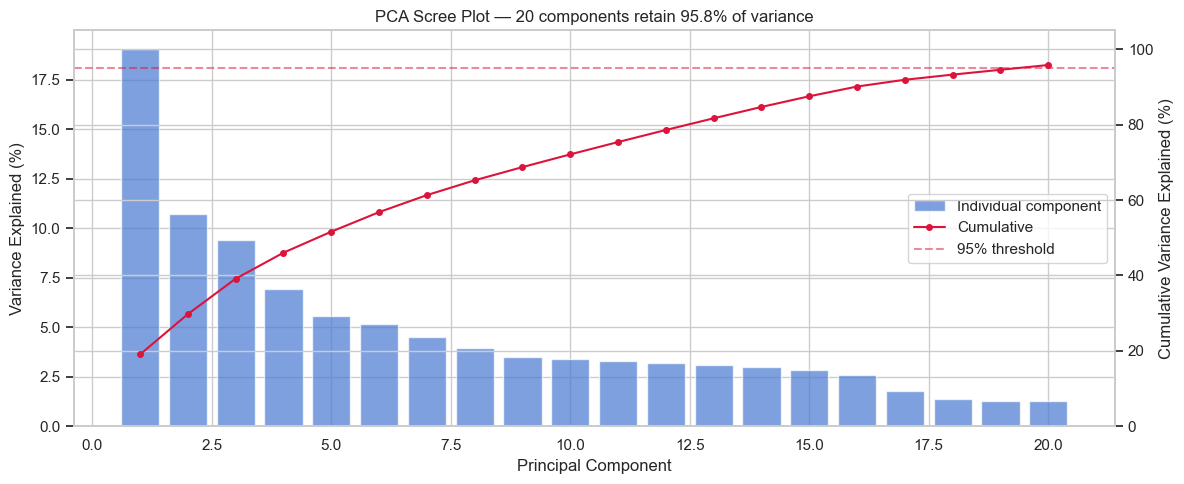

In [3]:
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(1, len(explained) + 1), explained * 100, alpha=0.7, label="Individual component")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, color="crimson", marker="o", markersize=4, label="Cumulative")
ax2.axhline(95, color="crimson", linestyle="--", alpha=0.5, label="95% threshold")
ax2.set_ylabel("Cumulative Variance Explained (%)")
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

ax1.set_title(f"PCA Scree Plot — {pca.n_components_} components retain {cumulative[-1]:.1%} of variance")
plt.tight_layout()
plt.show()

## 2. Component loadings — what does each component measure?

Each principal component is a weighted combination of the original features. The loadings tell us which original features are driving each component.

For example, if PC1 loads heavily on `velocity_ratio_7d_vs_30d`, `burst_event_count`, and `trades_per_day_7d`, we'd interpret PC1 as a "trading velocity" axis. This helps us explain the model's behavior in human terms.

In [4]:
n_components_to_show = min(5, pca.n_components_)
loadings = pd.DataFrame(
    pca.components_[:n_components_to_show].T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(n_components_to_show)]
)

fig, axes = plt.subplots(1, n_components_to_show, figsize=(4 * n_components_to_show, 7), sharey=True)

for i, pc in enumerate(loadings.columns):
    sorted_loadings = loadings[pc].sort_values()
    colors = ["crimson" if v < 0 else "steelblue" for v in sorted_loadings]
    axes[i].barh(sorted_loadings.index, sorted_loadings.values, color=colors)
    axes[i].set_title(f"{pc}\n({pca.explained_variance_ratio_[i]:.1%} var)", fontsize=10)
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].tick_params(labelsize=8)

fig.suptitle("Top Feature Loadings per Principal Component", fontsize=12)
plt.tight_layout()
plt.show()

ValueError: Shape of passed values is (33, 5), indices imply (35, 5)

## 3. Top features driving each component

Table view of the top 5 features (by absolute loading) for each of the first five components.

In [ ]:
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc} — top 5 features:")
    for feat in top.index:
        val = loadings.loc[feat, pc]
        print(f"  {feat:<45} {val:+.3f}")

## 4. Visualize accounts in PC1 vs. PC2 space

Project all accounts into the first two principal components and plot them as a scatter. If the injected anomaly accounts (red) cluster away from the main population (blue), it's a strong early signal that the feature space is doing its job — before we even run a model.

In [ ]:
# Scale then project through PCA
X = features[feature_cols].fillna(features[feature_cols].median())
X_scaled = scaler.transform(X)
X_pca = pca.transform(X_scaled)

pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["is_injected"] = features["is_injected"].values

fig, ax = plt.subplots(figsize=(10, 7))

normal  = pca_df[~pca_df["is_injected"]]
anomaly = pca_df[pca_df["is_injected"]]

ax.scatter(normal["PC1"], normal["PC2"], alpha=0.3, s=15, label="Normal accounts", color="steelblue")
ax.scatter(anomaly["PC1"], anomaly["PC2"], alpha=0.9, s=60, label="Injected anomalies", color="crimson", zorder=5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Accounts in PCA Space (PC1 vs. PC2)")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Color by anomaly pattern

Break the injected accounts out by pattern to see if different anomaly types occupy different regions of PCA space — which would indicate the features are capturing meaningfully different behaviors.

In [ ]:
pca_df["account_id"] = features["account_id"].values
pca_df = pca_df.merge(injected[["account_id", "anomaly_pattern"]], on="account_id", how="left")
pca_df["anomaly_pattern"] = pca_df["anomaly_pattern"].fillna("Normal")

palette = {
    "Normal": ("steelblue", 0.2, 12),
    "wash_trading":         ("crimson",    0.9, 60),
    "velocity_spike":       ("darkorange", 0.9, 60),
    "smurfing":             ("purple",     0.9, 60),
    "illiquid_concentration":("green",     0.9, 60),
    "off_hours_clustering": ("brown",      0.9, 60),
}

fig, ax = plt.subplots(figsize=(11, 7))

for pattern, (color, alpha, size) in palette.items():
    subset = pca_df[pca_df["anomaly_pattern"] == pattern]
    if len(subset) > 0:
        ax.scatter(subset["PC1"], subset["PC2"], alpha=alpha, s=size, label=pattern, color=color, zorder=5 if pattern != "Normal" else 1)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA Space — Colored by Anomaly Pattern")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()